# 딥러닝 ② FOCUS ON TRANSFORMER

## 1. 인트로  
  
### 1-1. RNN 한계와 어텐션의 등장  
  
**RNN의 한계**: 장기 의존성 문제, Vanishing gradient  
  
**Attention의 등장**  
- Seq2Seq의 병목 현상
    - Context Vector로 압축하는 과정에서 정보 소실 문제 발생
    -> Attention 등장!  

**Attention**  
- 중요한 정보에 더 집중하는 메커니즘
    - 입력값의 모든 부분을 똑같이 참고하는 것이 아니라, 현재 시점에서 가장 중요한 부분에 더 높은 가중치를 부여
- 병렬화: 출력 시점마다 새로운 Context Vector를 동적으로 계산
  

[과정]  
1. 입력 형태를 숫자 벡터로 변환
2. 단어별 중요도 계산
    - 관련도 점수 계산(Score): 단어들 사이의 관계나 유사성 측정
    - 중요도 배분(Softmax): 위 점수를 0~1사이로 변환하여 모든 중요도의 합이 1이 되도록 조정
3. 중요도에 따른 입력 정보 조합
    - 2단계에서 계산된 어텐션 가중치에 따라 높은 단어의 정보 더 많이 반영, 낮은 단어의 정보를 적게 반영하여 최종 결과로 생성

[장점]  
1. 시간 경과에 대한 유연성 (vs RNN)
    - RNN은 장기 의존성 문제를 가짐
    - Attention은 모든 단어에서 다른 모든 단어로 직접 연결될 수 있음 -> 시간적(순서적) 거리에 제약을 받지 않는 유연성 확보
2. 공간에 대한 유연성 (vs CNN)
    - CNN은 고정된 필터를 사용해 이미지의 지역적인 부분을 중심으로 정보를 처리
    - Attention은 이미지의 모든 픽셀이 다른 모든 픽셀과 직접 연결되어 한 번에 전체 이미지의 전역적인 관계를 학습할 수 있음 -> 이미지 내 복잡한 상호작용을 유연하게 포착 가능
3. 병렬화 (vs RNN)
    - RNN은 구조적으로 순차 계산이 필수 -> 병렬 처리 어렵고, 학습 속도 느림
    - Attention은 self-attention에서 문장 내 모든 단어의 관계를 한번에, 독립적으로 계산할 수 있음 -> 병렬 처리 가능, 긴 시퀀스도 더 효율적으로 학습

### 1-2. Attention is all you need  
  
> Transformer 구조를 처음 발표한 Google Brain의 논문  
  
[논문 내용]  
1. 배경: RNN과 RNN 기반 모델들의 한계
    - 느린 학습 속도, 장기 의존성 문제
    -> 순차적 계산 구조를 제거하고, 인코더부터 디코더까지 오직 Attention만을 사용하는 모델을 만들면 어떨까?  

2. Transformer 등장
    - RNN의 순환 구조를 완전히 제거하고, self-attention에 기반한 Transformer 모델을 제안
  
3. 발견
    - 성공적인 모델링에 Recurrence 및 Convolution이 필수가 아님을 증명
    - 기존 RNN 기반 모델들이 사용하던 순환구조 없이도 Attention만으로 더 좋은 성능을 낼 수 있음을 보여줌
    - 모든 단어를 동시에 계산하는 병렬화가 가능해짐
    -> 학습 속도 단축, 거대한 데이터 다룰 수 있음

4. 파급효과
    - LLM 탄생: 트랜스포머는 BERT와 GPT라는 두 거대 모델의 직접적 기반이 됨
    - NLP 평정: 번역, 요약, 챗봇 등 거의 모든 자연어 처리 분야에서 트랜스포머 기반 모델들이 표준으로 자리 잡게 됨
    - 타 분야로 확장: 컴퓨터 비전, 음성 처리, 신약 개발 등 모든 영역으로 확장 시킴

**Transformer**: RNN의 순차적인 계산 방식을 완전히 버리고, 오직 어텐션만으로 문장의 의미와 구조를 파악하는 모델  
  
[핵심 기술]  
1. Self-Attention: 문장 안에서 어떤 단어가 다른 단어들과 얼마나 중요한 관계를 맺고 있는지 한 번에 파악
2. Multi-Head Attention: 셀프 어텐션을 여러 개의 Head로 동시에, 서로 다른 관점에서 실행
3. Positional Encoding: 단어의 위치 정보를 벡터에 추가하여 각 단어가 문장의 몇 번째 위치에 존재하는지 알 수 있음
  
[이전과의 차이]  
- 기존 모델: RNN 기반 Encoder/Decoder + Attention
- Transformer: Attention 기반 Encoder/Decoder

## 2. Self-Attention  
  
### 2-1. Query, Key, Value  
  
**Query**: 지금 내가 알고 싶거나 초점을 맞추고 있는 대상, 질문 또는 요청  
**Key**: 검색 대상이 되는 모든 정보들이 달고 있는 이름표 또는 색인, 이 키들과 자신을 비교하며 얼마나 관련이 있는지 확인  
**Value**: 키와 한 쌍으로 묶여 있는 실제 내용물, 쿼리와 키의 관련도 계싼이 끝나고 가장 관련성이 높다고 판단된 키가 선택되면 모델은 그 키에 해당하는 밸류를 가져와 사용  
  

### 2-2. 기존 Cross-Attention vs Self-Attention  
  
**기존 Attention in Seq2Seq (Cross-Attention)**  
  
> 하나의 시퀀스가 완전히 다른 시퀀스를 참고하여 정보를 만들어내는 메커니즘 -> 디코더가 인코더를 참고하는 과정  
  
- 디코더가 출력할 때 계속해서 입력값의 어느 부분을 참고할지 결정하는 과정 -> 두 개의 서로 다른 정보 소스를 연결하는 다리 역할

[과정]  
1. Query 만들기: 디코더는 지금까지 생성된 단어들을 보고 현재 상태를 하나의 벡터(Query)로 요약
2. Key, Value 불러오기: 인코더는 입력 문장을 처리해 각 단어에 대한 벡터를 가짐
3. 유사도 계산: 디코더의 쿼리가 인코더의 각 키와 유사도를 계산 (Q·K_i) 내적 -> 이 점수들을 Softmax로 정규화해서 전체가 1이 되도록 가중치로 변환
4. Weighted Sum: 인코더의 밸류들을 그 가중치로 섞어줌
5. 디코더가 다음 단어를 예측: 자기 자신의 정보와 방금 만든 Context Vector를 합쳐서 다음에 올 단어를 예측
  
  
**Self-Attention**  
  
> 문장 자체를 뜯어보며 내부의 관계를 파악  
  
- Query와 Key-Value 쌍이 같은 시퀀스에서 출력
- 문장 스스로가 문맥을 이해하는 과정
  
[과정]  
1. 단어의 프로필 만들기 (벡터 임베딩)
    - 원시 데이터 시퀀스를 읽고, 각 시퀀스 요소를 의미론적 특성과 같은 속성을 수치적으로 반영하는 고유한 특성 벡터로 표현
2. 단어 간 관계 점수 계산 (내정 및 정렬 점수): 관계 깊을수록 점수 높음
    - 대부분 내적을 계산하여 걸졍
3. 중요도 배분 (소프트맥스&어텐션 가중치): 관계 점수를 총합이 1이 되는 확률값, 즉 Attention Weight로 변환
    - 정렬 점수를 Softmax 함수에 입력하여 모든 값을 0~1 사이로 정규화
4. 새로운 벡터 생성: 위 가중치를 바탕으로 각 단어는 문장 내 다른 단어들의 정보를 자신에게 맞게 조합 -> 문맥이 완벽하게 반영된 새로운 프로필(벡터)가 됨
  
  
### 2-3. Sclaed Dot-Product Attention  
  
**Dot-Product Attention**: Attention Score를 계산하는 가장 기본적인 방법, 쿼리와 키 벡터를 내적하여 유사도 구함  
  
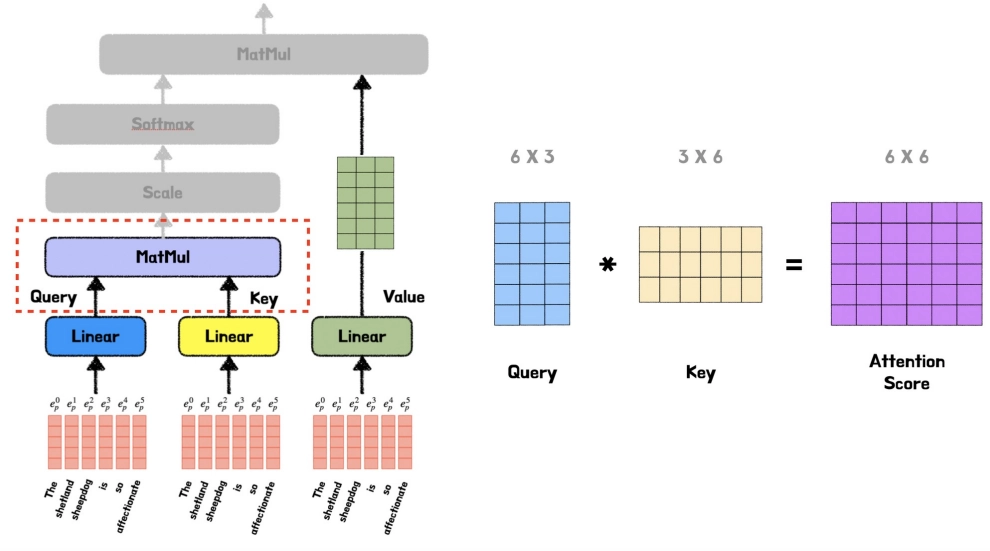  
  
[과정]  
1. 쿼리 벡터와 모든 키 벡터를 내적하여 유사도 계산 진행
2. 계산된 값에 Softmax 함수를 적용하여 총합이 1인 Attention Weight 산출
3. 이 가중치를 밸류 벡터에 곱하여 최종 결과값 계산
  
[문제점]  
- Attention Score의 극단화
    - 벡터 차원이 커질수록 내적값이 지나치게 커지거나 작아질 수 있음 -> 이런 극단적인 값이 Softmax에 입력되면 특정 단어에 확률이 과도하게 집중되고, gradient가 0에 가까워지는 Vanishing Gradient 문제 발생할 수 있음

**Sclaed Dot-Product Attention**: Transformer의 어텐션 계산 공식 자체, 기존의 Dot-Product Attention 문제 해결  
-> Dot-Product Attention 과정에서 내적 진행한 후, 값의 크기를 마추는 스케일링 과정 추가  
  
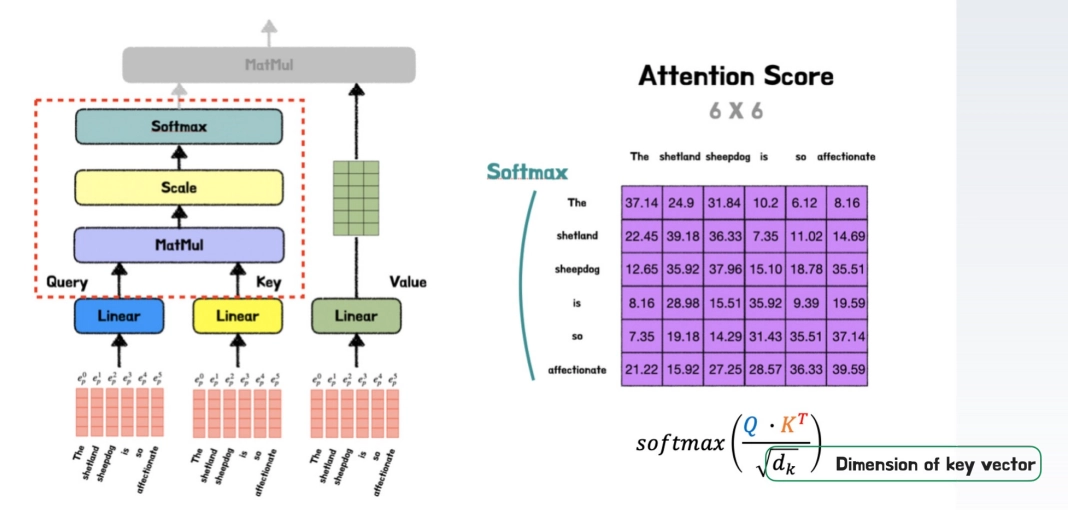  
  
- 유사도 계산 값을 $\sqrt{d_K}$로 나누어 스케일링 진행
- 한 번의 나눗셈으로, 계산된 내적 값이 과도하게 증가하는 것 방지 -> 안정적인 분포 형성 -> Softmax 함수가 안정적으로 학습 진행할 수 있도록 함
- 결과적으로 얻어지는 벡터
    - Cross-Attention: 현재 생성 중인 단어가 입력 문장에서 어떤 단어들에 집중해야 하는지를 반영한 Context Vector
    - Self-Attention: 문장 내 다른 단어들과의 관계를 반영한 문맥적 표현

## 3. Multi-Head Attention  
  
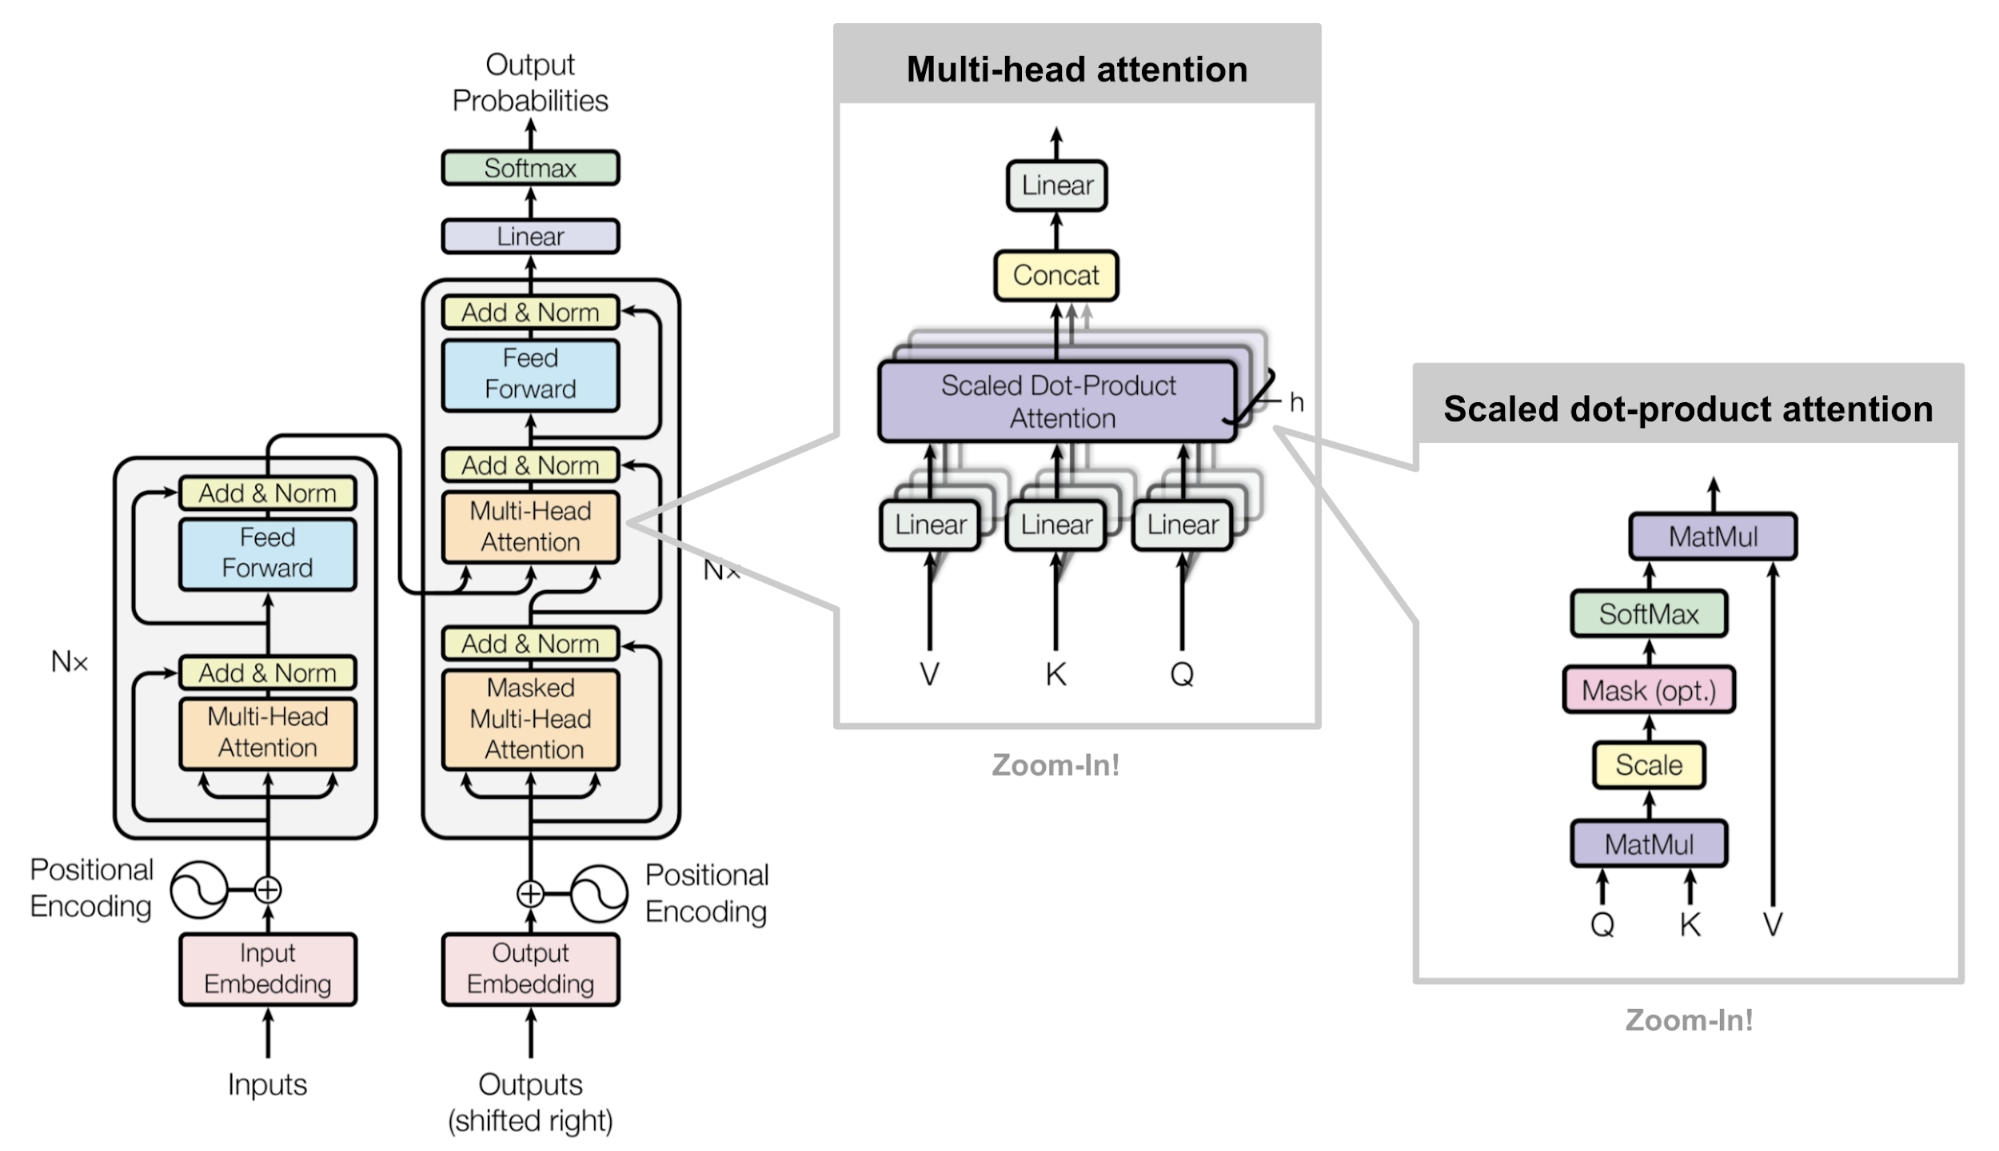  
  
- Encoder - Multi-Head Attention 한 번 사용
- Decoder - Multi-Head Attention 두 번 사용
    - Masked Multi-Head Attention: 아직 생성되지 않은 미래 단어를 보지 못하도록 가리고, 현재까지 생성된 단어들만 참고
    - Encoder-Decoder Attention: Decoder가 출력을 생성할 때, Encoder가 이해한 입력 문장 정보를 참고
- 트랜스포머가 토큰들 사이의 관계를 파악하고, 문맥 정보를 반영하여 더 정확한 출력을 만들 수 있도록 도와주는 핵심 구조
  

### 3-1. Why Multi-Head Attention?  
  
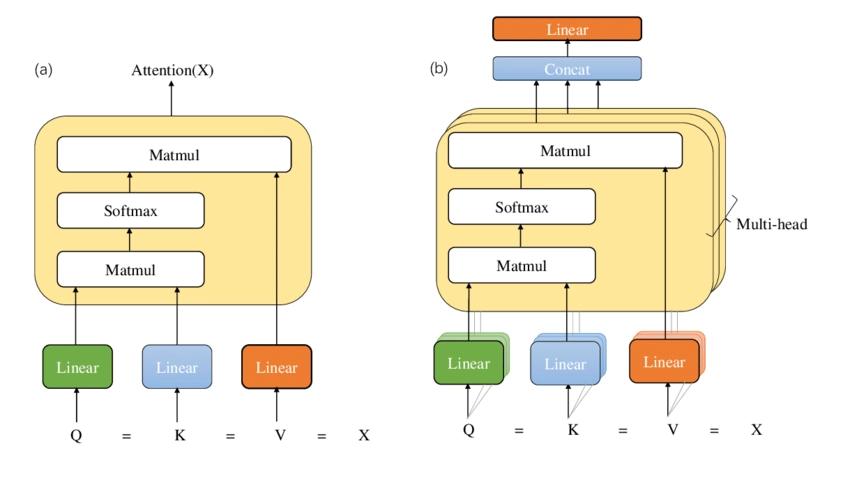  
  

**Single-Head Attention**  
- 문장 내 단어들 간 관계를 파악하기 위해 하나의 가중치 행렬($W^Q, W^K, W^V$)만을 학습하고 번역에 사용
- 작동 방식
    1. 512 차원의 입력 벡터
    2. 이 벡터를 위한 어텐션 가중치 분포 계산
    3. 가중합하여 새로운 512차원의 벡터 출력
- 한계
    - 하나의 어텐션 분포 안에서 각 단어 간 문법적인 관계, 의미적인 관계, 위치 관계 등 모든 종류의 정보를 한 번에 담아 가중 평균 구함 -> 결국 각 단어 간 중요한 관계를 놓칠 수 있음
  
**Multi-Head Attention**  
- 한 단어와 다른 단어 간의 관계를 여러 차원으로 나누어 병렬로 학습
- Attention is all you need의 경우, 512차원의 벡터를 64차원씩 8개의 벡터로 나누고, Attention 스코어를 병렬로 여러번 계산
  

### 3-2. Multi-Head Attention 작동 방식  
  
1. 분할: 8개의 헤드에 단어 벡터 할당
    - 입력 벡터에 8세트의 다른 가중치 행렬을 곱함
    - Q, K, V 세트로 분할
  
2. 병렬 어텐션 계산: 각 헤드들이 각자 분석 수행
    - 8개 헤드는 서로 간섭하지 않고 병렬로 Scaled Dot-Product Attention 계산
    - 각 헤드 내부에서는 다음 과정으로 작동
        1. 점수 계산: 쿼리 벡터와 키 벡터를 내적하여 관련성 점수 계산
        2. 크기 조절: 계산된 점수들을 각 헤드 차원의 제곱근으로 나눠줌 (제곱근8)
        3. 가중치 변환: 조절된 점수들에 Softmax 함수를 적용하여 총하빙 1인 어텐션 가중치 만듦
        4. 가중합: 이 가중치를 문장 내 모든 단어의 밸류 벡터에 곱한 뒤 모두 더함
    - 이 결과로 헤드 1의 관점에서 문맥을 이해한 64차원의 결과 벡터가 나옴
  
3. 결합 및 최종 투영: 8개의 헤드가 내놓은 8개의 분석 결과를 하나로 합침
    - 결합: 8개의 64차원 결과 벡터를 순서대로 이어 붙여 하나의 거대한 512차원 벡터를 만듦
    - 최종 투영: 나열된 정보들을 잘 융합하고 최종적으로 정리하기 위해 또 다른 가중치 행렬을 곱해줌
    - 결과적으로 8개의 서로 다른 관점에서 분석된 정보가 조화롭게 융합된 벡터가 최종 출력 됨

## 4. Transformer 전체 아키텍처  
  
### 4-1. 트랜스포머 전처리 단계  
  
> 트랜스포머 작동 과정: 텍스트 입력 받기 -> 텍스트 토큰화 -> 토큰 임베딩 -> 포지셔널 인코딩 -> 인코더 레이어에서 실질적인 연산 수행  
  
1. 토큰화: 입력 텍스트를 모델이 처리할 수 있는 단위로 나눔
  
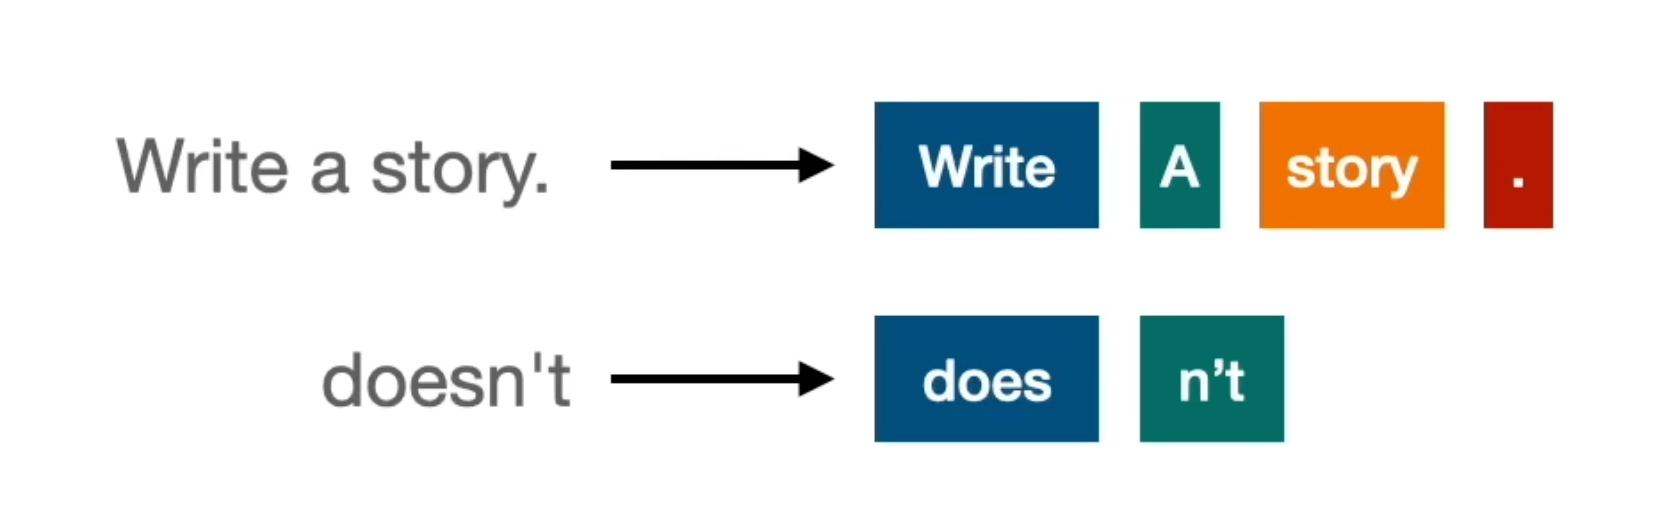  
  
[방법]  
- 대부분의 경우 각 토큰은 하나의 단어에 해당
- 문장 부호 역시 별도의 토큰
- 일부 단어는 하나 이상의 토큰으로 나뉠 수 있음 (ex. doesn't->does, n't)
  
2. 임베딩: 각 토큰을 숫자 벡터로 변환
  
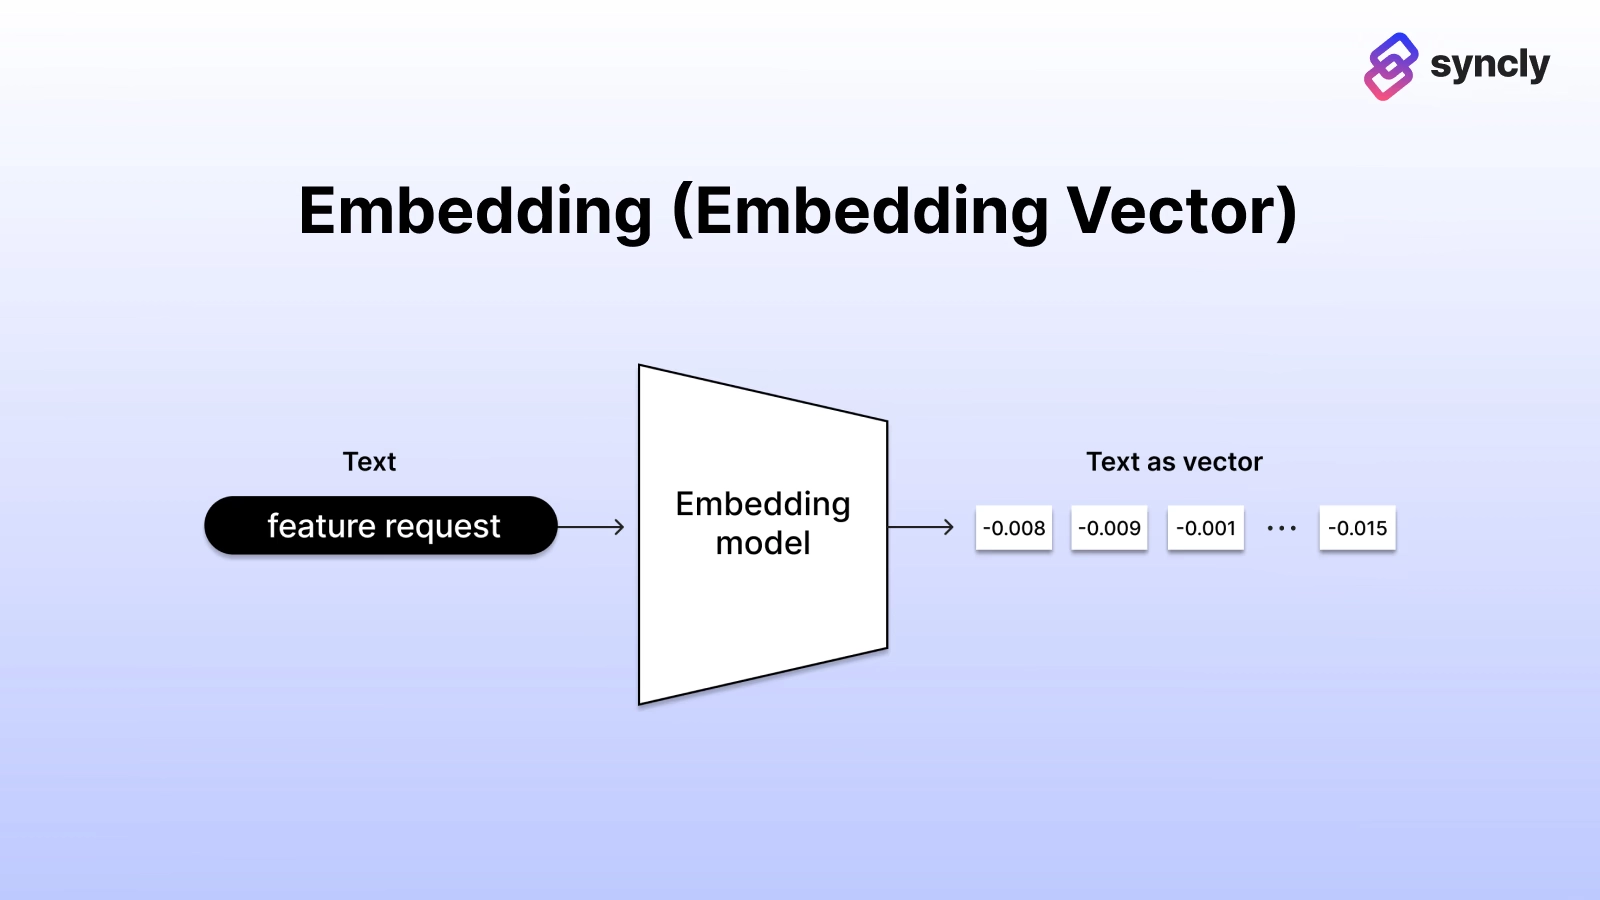  
  
- 단어의 의미를 공간적으로 표현
    - 유사한 단어는 유사한 숫자로 변환되어야 함
      
    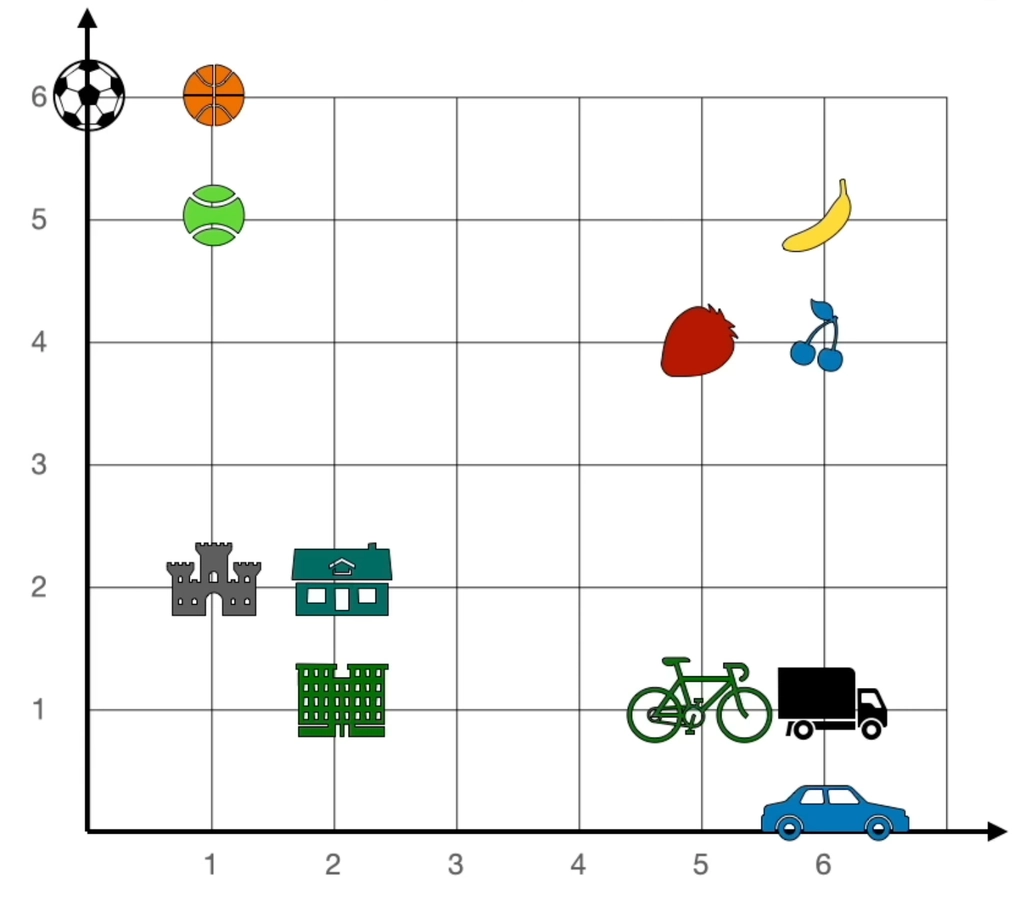  
      
3. Positional Encoding: 단어들의 순서 정보를 임베딩 벡터에 추가
  
- Transformer는 모든 단어를 병렬로 처리해서 단어의 순서 알지 못함 -> 문맥을 파악하기 위해서는 순서가 중요하므로 순서 정보를 제공
- 각 단어의 임베딩 좌표에 일관된 순서를 따르는 숫자를 추가하여 순서 정보를 기록
    - 일관된 순서: 위치에 따라 정해진 수정 벡터를 적용

### 4-2. 트랜스포머의 Encoder와 Decoder  
  
1. Encoder: 입력 문장을 이해하고 요약된 의미 벡터로 변환하는 역할, 전처리 과정 및 인코더 레이어로 구성되어 있음
  
[구성]  
  
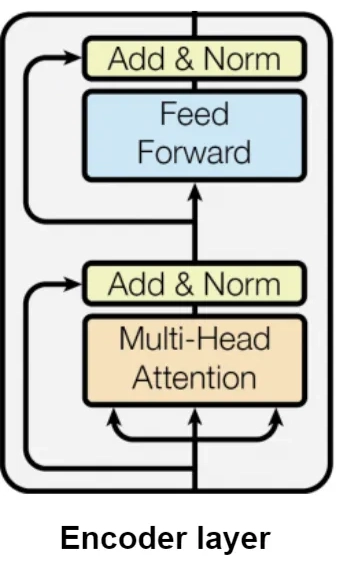  
  
1. Multi-Head Attention
2. Feed-Forward(FFN): 입력 벡터의 차원을 확장하고 비선형 변환(ex. ReLU)을 적용하여 새로운 표현을 생성하는 신경망 구조
    - MLP가 2층으로 완전 연결된 구조
    - 단어에 대한 심층 분석
  
[Add&Norm]
**잔차 연결**: 입력 값을 그대로 출력에 더해 주는 것  
  
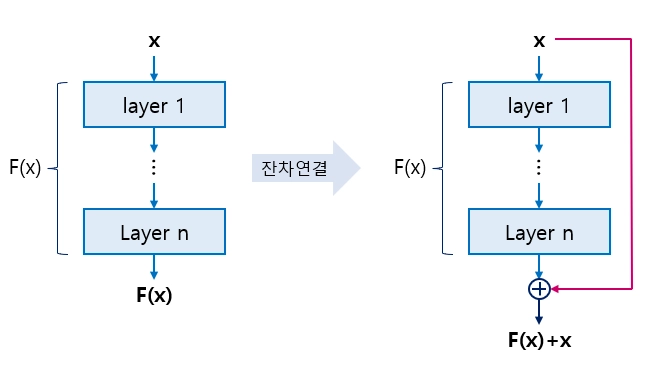  
  
- 층이 쌓이게 되면 기울기 소실 혹은 폭주 현상이 발생할 수 있는데, 출력에 입력값을 바로 전달하여 이러한 문제를 방지
  
**층 정규화**: 입력 벡터의 평균과 분산을 사용해서 정규화하여 학습을 안정화하고 모델이 빠르게 수렴하게 만듦  
  

2. Decoder: 인코더가 분석한 입력 문장의 의미벡터를 받아서 출력 문장을 순차적으로 생성, 전처리 과정, 디코더 레이어, 선형 레이어, 소프트맥스 레이어로 이루어져 있음  
  
[구성]  
  
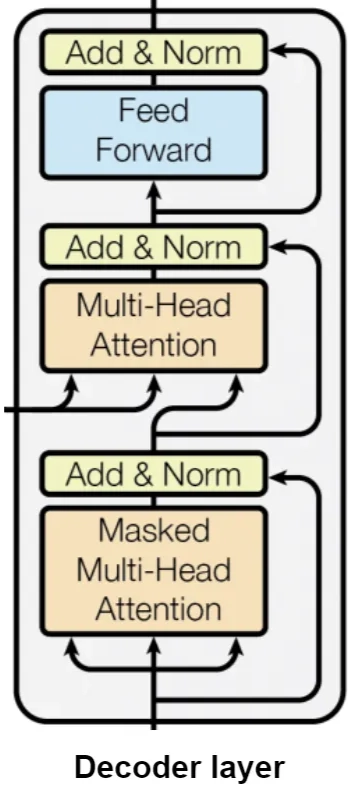  
  
1. Masked Multi-Head Attention: 미래 시점의 단어 정보를 참고하지 못하도록 마스크를 적용하는 어텐션 매커니즘
    - 트랜스포머의 디코더는 시퀀스를 왼쪽에서 올ㄴ쪽으로 생성하며, 모델이 이미 생성된 단어(과거 정보)를 기반으로 다음 단어 예측하도록 강제
    - 이를 위해 Look-Ahead Mask를 사용하여 현재 단어보다 오른쪽(미래)에 있는 토큰의 어텐션 값을 0으로 만들어 무시
2. Encoder-Decoder Multi-Head Attention (Cross-Attention): 디코더가 인코더의 출력을 참고하면서 현재 생성 중인 단어를 입력 문장의 의미와 연결하는 과정
    - Query: 디코더의 이전 서브레이어 출력
    - Key, Value: 인코더의 최종 출력
    - 디코더가 입력 문장 중 어디에 주목해야 하는지 학습
3. Feed-Forward Layer
  

### 4-3. 전체 모델 및 데이터 흐름  
  
1. 입력 준비: 문장을 [의미+위치] 벡터로 수정
    - 임베딩: 각 단어를 의미를 담은 숫자 벡터로 변환
    - 포지셔널 인코딩: 순서 정보를 알 수 없으므로, 각 단어의 위치에 해당하는 벡터를 의미 벡터에 더함

2. 인코더: 입력 문장의 [문맥적 의미] 깊이 이해하기
    - 셀프 어텐션: 해당 단어가 문장에서 어떤 의미를 갖는지 파악
    - 관계 점수 계산: Q와 K의 내적으로 관계 점수 구하고, softmax로 확률 분포로 변환
    - 가중합: 계산된 가중치를 밸류 벡터에 곱하고 모두 더하여 새로운 벡터 생성
    - 멀티-헤드: 여러 개의 어텐션 헤드를 통해 다양한 관점에서 문맥 파악

3. 디코더: 번역 문자을 [한 단어 씩] 생성하기
    - Masked Self-Attention: 과거에 나온 단어만을 참고하여 문맥 형성
    - Encoder-Decoder Attention: 인코더의 출력을 참고하면서 현재 생성 중인 단어 의미와 연결
